# Experimentos con Covariables 3.1–3.6

**Tesis MEC** — Comparación TSFMs vs Modelos Clásicos bajo DGPs controlados  
**Setup:** T ∈ {50, 200} | H = 24 | R_LIST = [500] | Semilla = 3649  
**Métricas punto:** Bias, Varianza, MSE, RMSE, MAE  
**Métricas probabilísticas:** CRPS, Cobertura 80%/95%, Amplitud 80%/95%, Winkler Score 80%/95%  
**Resultados:** guardados en `results/covariates/` — si existen se cargan sin re-simular

**Nota:** En todos los experimentos las covariables son *completamente observadas*: se proveen los valores históricos (`X_train`) y los valores futuros conocidos (`X_future`) a los modelos que los aceptan. Chronos-2 recibe las covariables vía la API de `past_covariates` / `future_covariates`. Los modelos sin soporte de covariables (ARIMA, VAR, Naive) reciben los mismos `X` pero los ignoran silenciosamente.

---

In [1]:
import os
import warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from mectesis.dgp import (
    ARIMAX_DGP, ARIMAX2Cov_DGP, ARIMAX_GARCH_DGP,
    VARX_DGP, ADL_ECM_DGP,
)
from mectesis.models import (
    ARIMAModel, SARIMAXModel, VARMAXModel, ARDLModel,
    VARModel, SeasonalNaiveModel,
    ARGARCHModel,
    ChronosModel, ChronosCovariateModel,
    ChronosMultivariateModel, ChronosPerVarModel,
    ChronosMultivariateCovariateModel,
)
from mectesis.simulation import (
    CovariateMonteCarloEngine, CovariateMultivariateEngine,
)

# ── Parámetros globales ───────────────────────────────────────────────────
SEED    = 3649
H       = 24
R_LIST  = [500]
T_LIST  = [50, 200]
RESULTS = Path("results/covariates")
RESULTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)

print("Cargando Chronos-2 (puede tardar ~30 s)...")
_chronos_base       = ChronosModel(device="cpu")
chronos_cov1        = ChronosCovariateModel(_chronos_base, n_covariates=1)
chronos_cov2        = ChronosCovariateModel(_chronos_base, n_covariates=2,
                          cov_names=["x0", "x1"])
chronos_mv_cov1     = ChronosMultivariateCovariateModel(_chronos_base, n_covariates=1)
chronos_mv          = ChronosMultivariateModel(_chronos_base)
chronos_mv_ind      = ChronosPerVarModel(_chronos_base)
print("Chronos-2 listo.")

Cargando Chronos-2 (puede tardar ~30 s)...
Chronos-2 listo.


In [2]:
# ─── Funciones auxiliares — experimentos con covariables ──────────────────

def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


# ── Univariate helpers ────────────────────────────────────────────────────

def _save_results(results: dict, path: Path):
    frames = []
    for mname, df in results.items():
        tmp = df.copy()
        tmp.insert(0, 'model', mname)
        frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results(path: Path) -> dict:
    df = pd.read_csv(path)
    return {
        mname: grp.drop(columns='model').reset_index(drop=True)
        for mname, grp in df.groupby('model', sort=False)
    }


def run_exp_cov(dgp, make_models_fn, dgp_params, exp_id,
                T_list=T_LIST, R_list=R_LIST, H=H, seed=SEED):
    """
    Corre MC con covariables para todas las combinaciones (T, R).
    Si el CSV ya existe, lo carga sin re-simular.
    Retorna {(T, R): {model_name: DataFrame}}.
    """
    n_runs = len(T_list) * len(R_list)
    combos = ', '.join(f'(T={t}, R={r})' for t in T_list for r in R_list)
    print(f'Exp {exp_id}: {n_runs} ejecución(es) programada(s) → {combos}')

    all_results = {}
    for T in T_list:
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                print(f'  T={T}, R={R}: cargando {cache.name} ...')
                all_results[(T, R)] = _load_results(cache)
                continue

            print(f'  T={T}, R={R}: simulando ...', end=' ', flush=True)
            dgp.rng = np.random.default_rng(seed)
            models  = make_models_fn(T)
            engine  = CovariateMonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, H, dgp_params, verbose=False)
            elapsed = time.time() - t0
            print(f'OK ({elapsed:.0f}s)')
            _save_results(results, cache)
            all_results[(T, R)] = results

    return all_results


def compute_blocks(results_TR: dict):
    out = {}
    for mname, df in results_TR.items():
        df_h = df[df["horizon"] != "avg_all"].copy()
        df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
        out[mname] = {
            "h=1-12":  df_h[df_h["horizon"] <= 12].mean(numeric_only=True),
            "h=13-24": df_h[df_h["horizon"] >= 13].mean(numeric_only=True),
        }
    return out


def results_table(all_results):
    """Tabla comparativa por (T, R, Modelo, Bloque) con gradiente en rmse/mae."""
    seen: dict = {}
    for res_TR in all_results.values():
        for df in res_TR.values():
            for c in df.columns:
                if c != 'horizon' and df[c].dtype != object:
                    seen[c] = True
    numeric_cols = list(seen)

    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        for mname, blks in compute_blocks(res_TR).items():
            for bname, m in blks.items():
                row = {'T': T, 'R': R, 'Modelo': mname, 'Bloque': bname}
                for col in numeric_cols:
                    if col in m.index:
                        row[col] = round(float(m[col]), 4)
                rows.append(row)

    df = pd.DataFrame(rows).set_index(['T', 'R', 'Modelo', 'Bloque'])
    grad_cols = [c for c in ['rmse', 'mae'] if c in df.columns]
    display(df.style.format(precision=4)
              .background_gradient(subset=grad_cols, cmap='YlOrRd'))


def plot_rep_cov(dgp, make_models_fn, dgp_params,
                 T=200, H=H, seed=SEED, title=''):
    """Simulación representativa con covariables — plot Y + forecasts."""
    import copy
    dgp_r = copy.deepcopy(dgp)
    dgp_r.rng = np.random.default_rng(seed)
    data = dgp_r.simulate(T=T, **dgp_params)
    y, X = data['y'], data['X']
    y_train, y_test = y[:-H], y[-H:]
    X_train, X_future = X[:-H], X[-H:]
    models = make_models_fn(T)

    palette = ['crimson', 'darkorange', 'seagreen', 'purple', 'teal', 'olive']
    fig, ax = plt.subplots(figsize=(13, 4))

    for m in models:
        fkw = {'X_train': X_train} if m.supports_covariates else {}
        m.fit(y_train, **fkw)

    x_tr = np.arange(len(y_train))
    x_te = np.arange(len(y_train), T)

    ax.plot(x_tr, y_train, color='steelblue', lw=1.4, alpha=0.85,
            label='Histórico')
    ax.plot(x_te, y_test, 'k--', lw=1.5, label='Observado (test)')
    ax.axvline(len(y_train) - 0.5, color='gray', ls=':', lw=1, alpha=0.6)

    for i, m in enumerate(models):
        pkw = {'X_future': X_future} if m.supports_covariates else {}
        y_hat = m.forecast(H, **pkw)
        ax.plot(x_te, y_hat, color=palette[i % len(palette)],
                lw=1.5, marker='o', ms=3, label=m.name)
        if m.supports_intervals:
            lo, hi = m.forecast_intervals(H, level=0.95, **pkw)
            ax.fill_between(x_te, lo, hi,
                            color=palette[i % len(palette)],
                            alpha=0.12, label='_nolegend_')

    ax.set(title=title, xlabel='t', ylabel='Y')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_metrics(all_results, title='', metrics=('rmse', 'bias')):
    """Grilla (metric × (T,R)) con curvas por modelo."""
    keys = sorted(all_results.keys())
    fig, axes = plt.subplots(
        len(metrics), len(keys),
        figsize=(7 * len(keys), 3.5 * len(metrics)),
        squeeze=False,
    )
    palette = ['crimson', 'darkorange', 'seagreen', 'purple', 'teal', 'steelblue']

    for col, (T, R) in enumerate(keys):
        for row, metric in enumerate(metrics):
            ax = axes[row][col]
            for i, (mname, df) in enumerate(all_results[(T, R)].items()):
                df_h = df[df["horizon"] != "avg_all"].copy()
                df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
                if metric not in df_h.columns:
                    continue
                ax.plot(df_h['horizon'], df_h[metric],
                        label=mname, color=palette[i % len(palette)], lw=1.5)
            ax.axvline(12.5, color='gray', ls=':', lw=0.8, alpha=0.5)
            ax.set(
                title=f'T={T}, R={R} — {metric.upper()}',
                xlabel='Horizonte h',
                ylabel=metric.upper(),
            )
            ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ── Multivariate helpers (re-used from gen_notebook_multivariate pattern) ──

def _save_results_mv(results: dict, path: Path):
    frames = []
    for mname, var_dict in results.items():
        for var_idx, df in var_dict.items():
            tmp = df.copy()
            tmp.insert(0, 'var', var_idx)
            tmp.insert(0, 'model', mname)
            frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results_mv(path: Path) -> dict:
    df = pd.read_csv(path)
    results = {}
    for mname, mgrp in df.groupby('model', sort=False):
        results[mname] = {}
        for var_idx, vgrp in mgrp.groupby('var', sort=True):
            results[mname][int(var_idx)] = (
                vgrp.drop(columns=['model', 'var']).reset_index(drop=True)
            )
    return results


def run_exp_mv_cov(dgp, make_models_fn, dgp_params, exp_id,
                   T_list=T_LIST, R_list=R_LIST, H=H, seed=SEED):
    n_runs = len(T_list) * len(R_list)
    combos = ', '.join(f'(T={t}, R={r})' for t in T_list for r in R_list)
    print(f'Exp {exp_id}: {n_runs} ejecución(es) programada(s) → {combos}')

    all_results = {}
    for T in T_list:
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                print(f'  T={T}, R={R}: cargando {cache.name} ...')
                all_results[(T, R)] = _load_results_mv(cache)
                continue

            print(f'  T={T}, R={R}: simulando ...', end=' ', flush=True)
            dgp.rng = np.random.default_rng(seed)
            models  = make_models_fn(T)
            engine  = CovariateMultivariateEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, H, dgp_params, verbose=False)
            elapsed = time.time() - t0
            print(f'OK ({elapsed:.0f}s)')
            _save_results_mv(results, cache)
            all_results[(T, R)] = results

    return all_results


def compute_blocks_mv(results_TR: dict):
    out = {}
    for mname, var_dict in results_TR.items():
        out[mname] = {}
        for var_idx, df in var_dict.items():
            df_h = df[df["horizon"] != "avg_all"].copy()
            df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
            out[mname][var_idx] = {
                "h=1-12":  df_h[df_h["horizon"] <= 12].mean(numeric_only=True),
                "h=13-24": df_h[df_h["horizon"] >= 13].mean(numeric_only=True),
            }
    return out


def results_table_mv(all_results, var_names=None):
    seen: dict = {}
    for res_TR in all_results.values():
        for var_dict in res_TR.values():
            for df in var_dict.values():
                for c in df.columns:
                    if c not in ('horizon',) and df[c].dtype != object:
                        seen[c] = True
    numeric_cols = list(seen)

    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        for mname, blk_dict in compute_blocks_mv(res_TR).items():
            for var_idx, blks in blk_dict.items():
                vname = var_names[var_idx] if var_names else f'Y{var_idx+1}'
                for bname, m in blks.items():
                    row = {'T': T, 'R': R, 'Modelo': mname,
                           'Variable': vname, 'Bloque': bname}
                    for col in numeric_cols:
                        if col in m.index:
                            row[col] = round(float(m[col]), 4)
                    rows.append(row)

    df = pd.DataFrame(rows).set_index(['T', 'R', 'Modelo', 'Variable', 'Bloque'])
    grad_cols = [c for c in ['rmse', 'mae'] if c in df.columns]
    display(df.style.format(precision=4)
              .background_gradient(subset=grad_cols, cmap='YlOrRd'))


def plot_rep_mv_cov(dgp, make_models_fn, dgp_params, var_names,
                    T=200, H=H, seed=SEED, title=''):
    import copy
    dgp_r = copy.deepcopy(dgp)
    dgp_r.rng = np.random.default_rng(seed)
    data = dgp_r.simulate(T=T, **dgp_params)
    y, X = data['y'], data['X']
    k = y.shape[1]
    y_train, y_test = y[:-H], y[-H:]
    X_train, X_future = X[:-H], X[-H:]
    models = make_models_fn(T)

    palette = ['crimson', 'darkorange', 'seagreen', 'purple', 'teal', 'olive']
    fig, axes = plt.subplots(k, 1, figsize=(13, 3.5 * k), squeeze=False)

    for m in models:
        fkw = {'X_train': X_train} if m.supports_covariates else {}
        m.fit(y_train, **fkw)

    x_tr = np.arange(len(y_train))
    x_te = np.arange(len(y_train), T)

    for j, ax in enumerate(axes[:, 0]):
        vname = var_names[j] if var_names else f'Y{j+1}'
        ax.plot(x_tr, y_train[:, j], color='steelblue', lw=1.4, alpha=0.85,
                label='Histórico')
        ax.plot(x_te, y_test[:, j], 'k--', lw=1.5, label='Observado (test)')
        ax.axvline(len(y_train) - 0.5, color='gray', ls=':', lw=1, alpha=0.6)

        for i, m in enumerate(models):
            pkw = {'X_future': X_future} if m.supports_covariates else {}
            y_hat = m.forecast(H, **pkw)
            ax.plot(x_te, y_hat[:, j], color=palette[i % len(palette)],
                    lw=1.5, marker='o', ms=3, label=m.name)
            if m.supports_intervals:
                lo, hi = m.forecast_intervals(H, level=0.95, **pkw)
                ax.fill_between(x_te, lo[:, j], hi[:, j],
                                color=palette[i % len(palette)],
                                alpha=0.12, label='_nolegend_')

        ax.set(title=f'{vname}', xlabel='t', ylabel=vname)
        ax.legend(fontsize=9)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_metrics_mv(all_results, var_names, title='',
                    metrics=('rmse', 'bias')):
    first_TR    = next(iter(all_results.values()))
    first_model = next(iter(first_TR.values()))
    k = len(first_model)

    for j in range(k):
        vname = var_names[j] if var_names else f'Y{j+1}'
        keys  = sorted(all_results.keys())
        fig, axes = plt.subplots(
            len(metrics), len(keys),
            figsize=(7 * len(keys), 3.5 * len(metrics)),
            squeeze=False,
        )
        palette = ['crimson', 'darkorange', 'seagreen', 'purple', 'teal', 'steelblue']

        for col, (T, R) in enumerate(keys):
            for row, metric in enumerate(metrics):
                ax = axes[row][col]
                for i, (mname, var_dict) in enumerate(
                        all_results[(T, R)].items()):
                    if j not in var_dict:
                        continue
                    df = var_dict[j]
                    df_h = df[df["horizon"] != "avg_all"].copy()
                    df_h["horizon"] = pd.to_numeric(
                        df_h["horizon"], errors="coerce")
                    if metric not in df_h.columns:
                        continue
                    ax.plot(df_h['horizon'], df_h[metric],
                            label=mname, color=palette[i % len(palette)],
                            lw=1.5)
                ax.axvline(12.5, color='gray', ls=':', lw=0.8, alpha=0.5)
                ax.set(
                    title=f'T={T}, R={R} — {metric.upper()}',
                    xlabel='Horizonte h',
                    ylabel=metric.upper(),
                )
                ax.legend(fontsize=8)

        fig.suptitle(f'{title} — {vname}', fontsize=12)
        plt.tight_layout()
        plt.show()

---
## Experimento 3.1

**DGP:** ARIMAX — efecto exógeno fuerte

$$Y_t = 0.6\,Y_{t-1} + 0.8\,X_t + \varepsilon_t, \quad X_t = 0.7\,X_{t-1} + \eta_t$$

**Modelos:** SARIMAX(1,0,0) con $X_t$, Chronos-2 con $X_t$ (past+future)

**Hipótesis:** El efecto exógeno $\beta=0.8$ es dominante; ambos modelos deben capturarlo. Chronos-2 debería aprovechar la señal exógena sin especificación explícita.

In [3]:
dgp_3_1         = ARIMAX_DGP(seed=SEED)
make_models_3_1 = lambda T: [
    SARIMAXModel((1, 0, 0), name_suffix='con X'),
    chronos_cov1,
]
dgp_params_3_1  = dict(phi=0.6, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)

results_3_1 = run_exp_cov(
    dgp_3_1, make_models_3_1, dgp_params_3_1,
    exp_id='3.1',
)

Exp 3.1: 2 ejecución(es) programada(s) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: cargando exp_3_1_T50_R500.csv ...
  T=200, R=500: cargando exp_3_1_T200_R500.csv ...


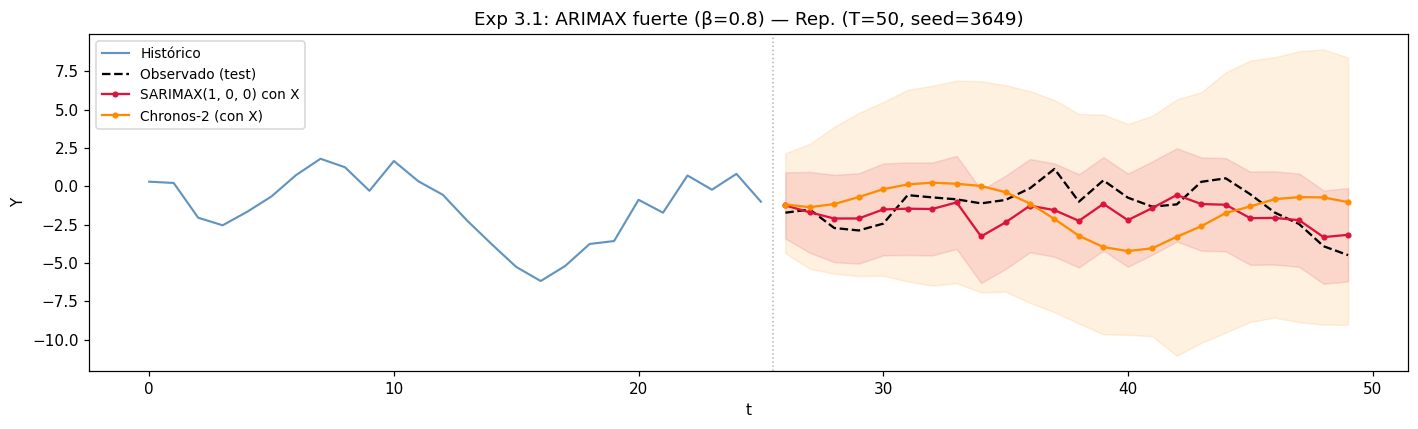

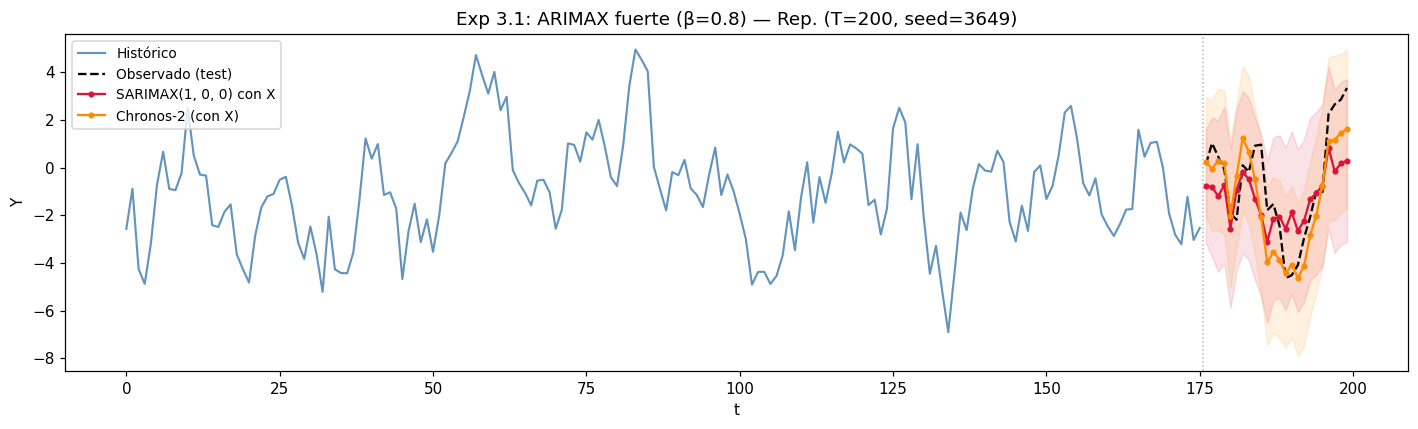

Tabla de métricas — Exp 3.1


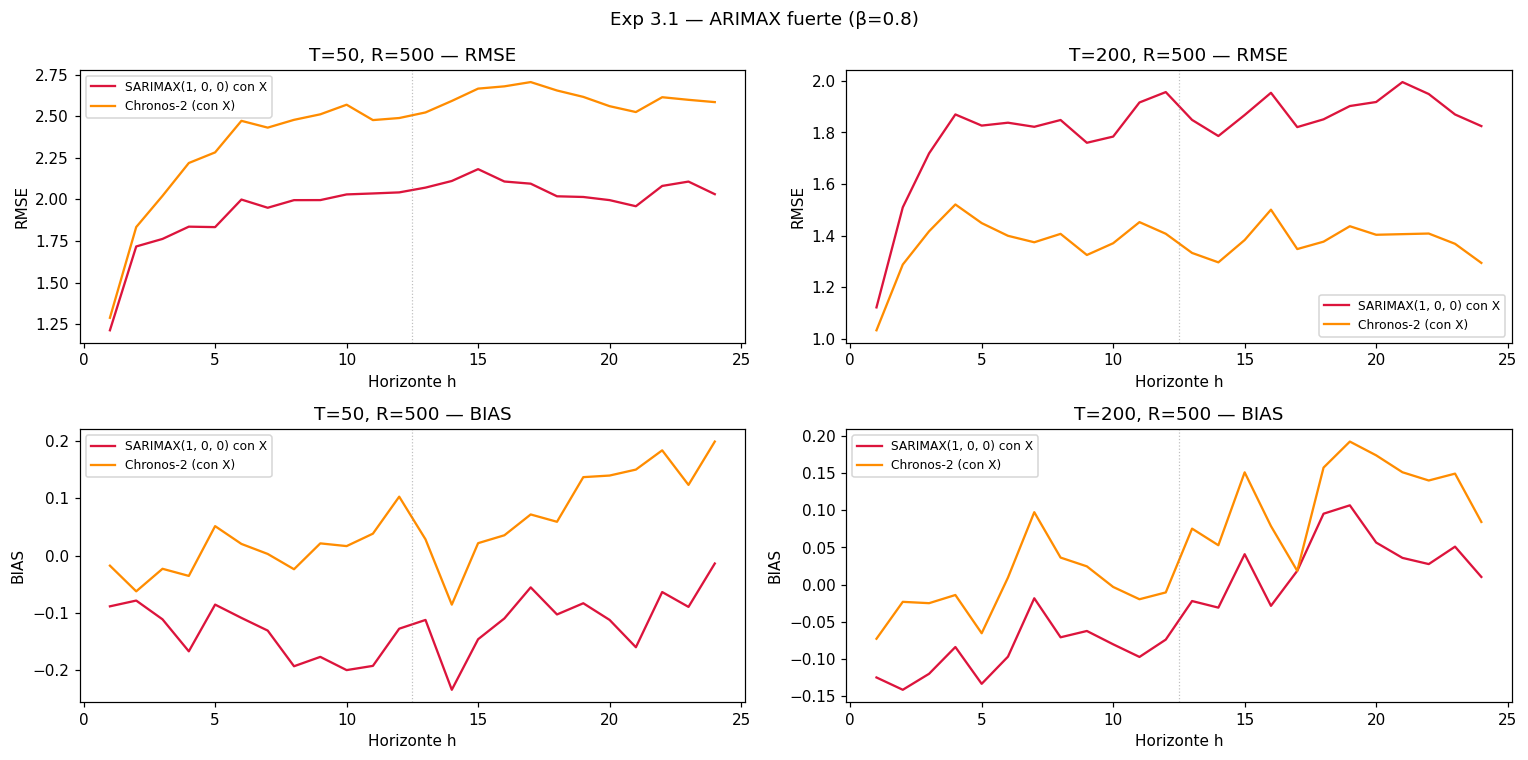

In [4]:
# Simulación representativa (T=T_LIST[0])
plot_rep_cov(
    dgp_3_1, make_models_3_1, dgp_params_3_1,
    T=T_LIST[0],
    title=f"Exp 3.1: ARIMAX fuerte (β=0.8) — Rep. (T={T_LIST[0]}, seed={SEED})"
)

# Simulación representativa (T=T_LIST[1])
plot_rep_cov(
    dgp_3_1, make_models_3_1, dgp_params_3_1,
    T=T_LIST[1],
    title=f"Exp 3.1: ARIMAX fuerte (β=0.8) — Rep. (T={T_LIST[1]}, seed={SEED})"
)

# Tabla de métricas
print("Tabla de métricas — Exp 3.1")
results_table(results_3_1)

# Gráficos de métricas por horizonte
plot_metrics(
    results_3_1,
    title=f"Exp 3.1 — ARIMAX fuerte (β=0.8)",
    metrics=("rmse", "bias")
)

---
## Experimento 3.2

**DGP:** ARIMAX — efecto exógeno débil

$$Y_t = 0.6\,Y_{t-1} + 0.2\,X_t + \varepsilon_t, \quad X_t = 0.7\,X_{t-1} + \eta_t$$

**Modelos:** SARIMAX(1,0,0) con $X_t$, Chronos-2 con $X_t$

**Hipótesis:** Con $\beta=0.2$ el efecto exógeno es débil; comparando con 3.1 se cuantifica cuán sensibles son los modelos al tamaño del efecto exógeno.

In [5]:
dgp_3_2         = ARIMAX_DGP(seed=SEED)
make_models_3_2 = lambda T: [
    SARIMAXModel((1, 0, 0), name_suffix='con X'),
    chronos_cov1,
]
dgp_params_3_2  = dict(phi=0.6, beta=0.2, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)

results_3_2 = run_exp_cov(
    dgp_3_2, make_models_3_2, dgp_params_3_2,
    exp_id='3.2',
)

Exp 3.2: 2 ejecución(es) programada(s) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: cargando exp_3_2_T50_R500.csv ...
  T=200, R=500: cargando exp_3_2_T200_R500.csv ...


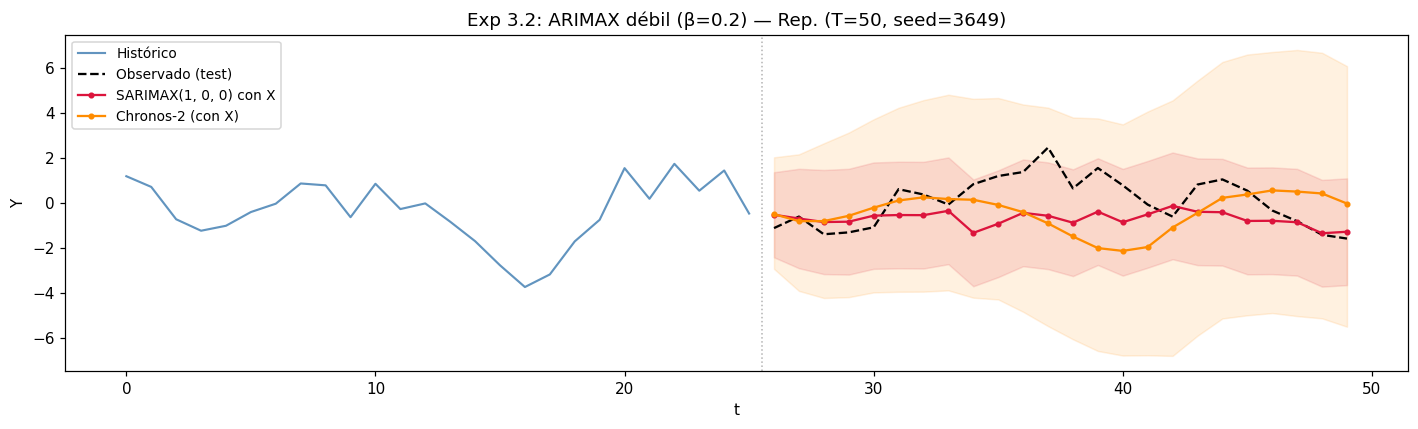

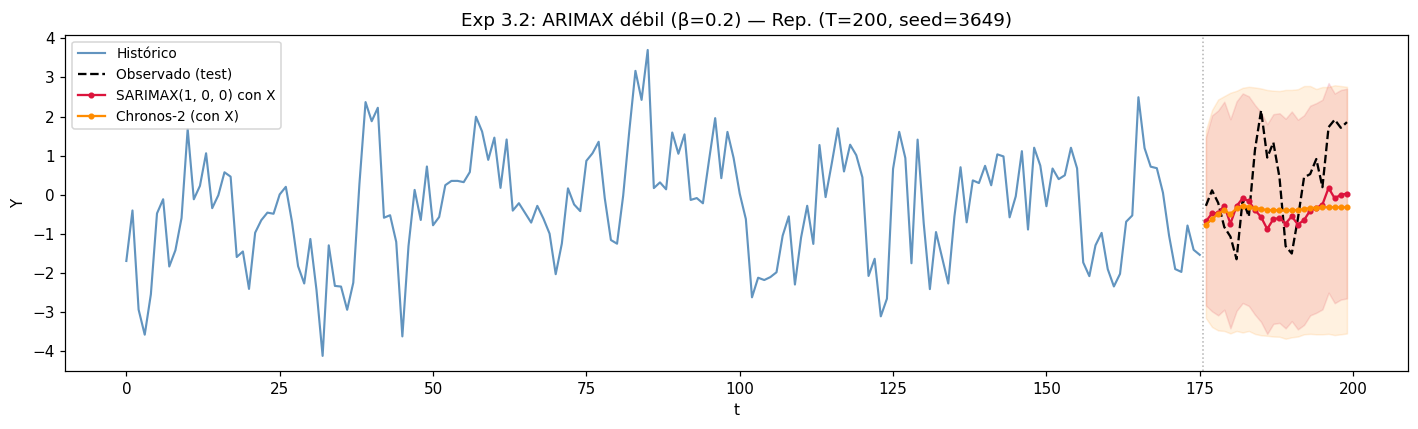

Tabla de métricas — Exp 3.2


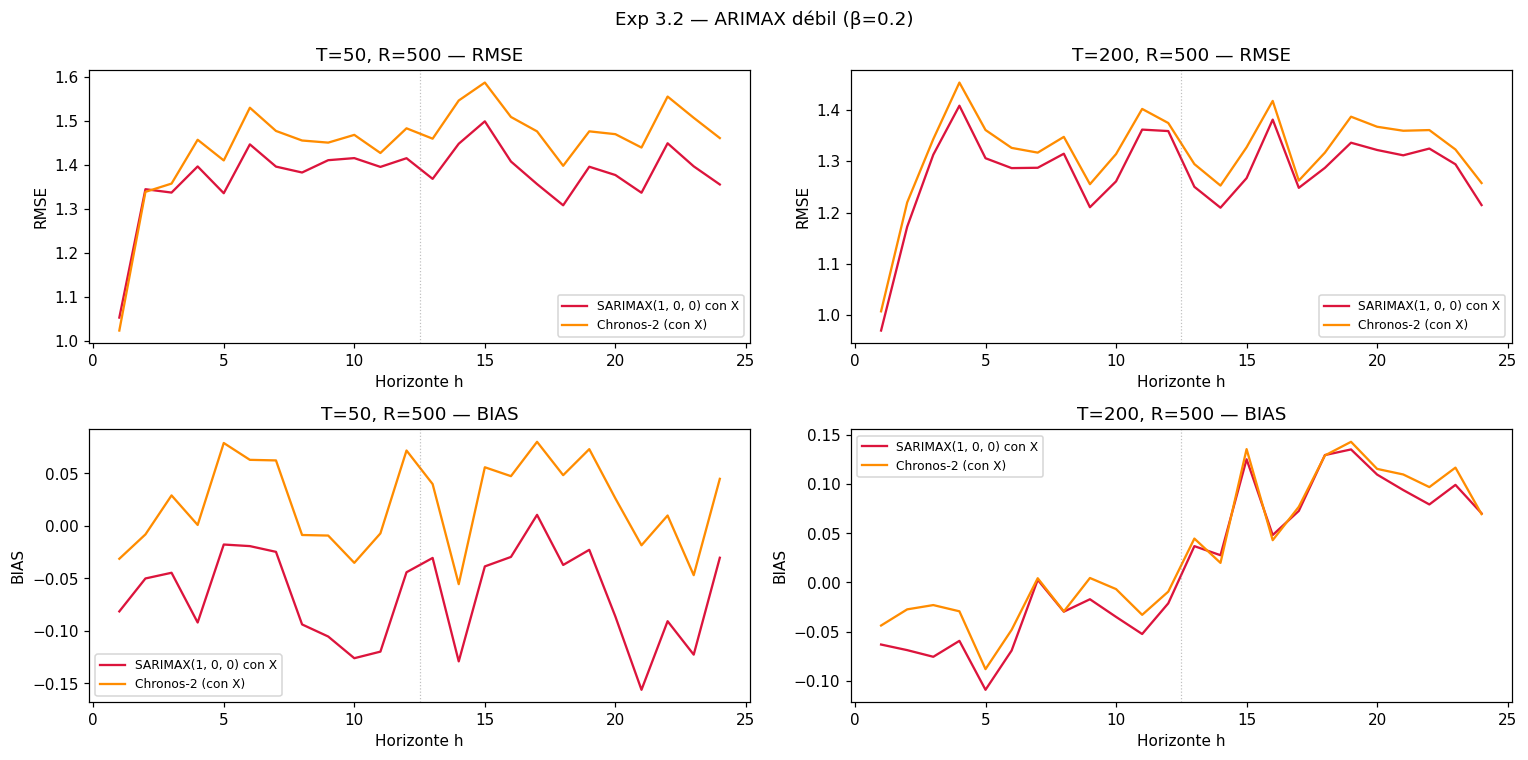

In [6]:
# Simulación representativa (T=T_LIST[0])
plot_rep_cov(
    dgp_3_2, make_models_3_2, dgp_params_3_2,
    T=T_LIST[0],
    title=f"Exp 3.2: ARIMAX débil (β=0.2) — Rep. (T={T_LIST[0]}, seed={SEED})"
)

# Simulación representativa (T=T_LIST[1])
plot_rep_cov(
    dgp_3_2, make_models_3_2, dgp_params_3_2,
    T=T_LIST[1],
    title=f"Exp 3.2: ARIMAX débil (β=0.2) — Rep. (T={T_LIST[1]}, seed={SEED})"
)

# Tabla de métricas
print("Tabla de métricas — Exp 3.2")
results_table(results_3_2)

# Gráficos de métricas por horizonte
plot_metrics(
    results_3_2,
    title=f"Exp 3.2 — ARIMAX débil (β=0.2)",
    metrics=("rmse", "bias")
)

---
## Experimento 3.3

**DGP:** ARIMAX con dos covariables independientes

$$Y_t = 0.6\,Y_{t-1} + 0.8\,X_{1t} + 0.4\,X_{2t} + \varepsilon_t$$

$$X_{i,t} = 0.7\,X_{i,t-1} + \eta_{i,t}, \quad i=1,2$$

**Modelos:** SARIMAX (con $X_1, X_2$), Chronos-2 con $(X_1, X_2)$

**Hipótesis:** SARIMAX especifica explícitamente los regresores; Chronos-2 debería explotar ambas señales sin especificación paramétrica.

In [7]:
dgp_3_3         = ARIMAX2Cov_DGP(seed=SEED)
make_models_3_3 = lambda T: [
    SARIMAXModel((1, 0, 0), name_suffix='2 cov.'),
    chronos_cov2,
]
dgp_params_3_3  = dict(phi=0.6, beta1=0.8, beta2=0.4, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)

results_3_3 = run_exp_cov(
    dgp_3_3, make_models_3_3, dgp_params_3_3,
    exp_id='3.3',
)

Exp 3.3: 2 ejecución(es) programada(s) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: cargando exp_3_3_T50_R500.csv ...
  T=200, R=500: cargando exp_3_3_T200_R500.csv ...


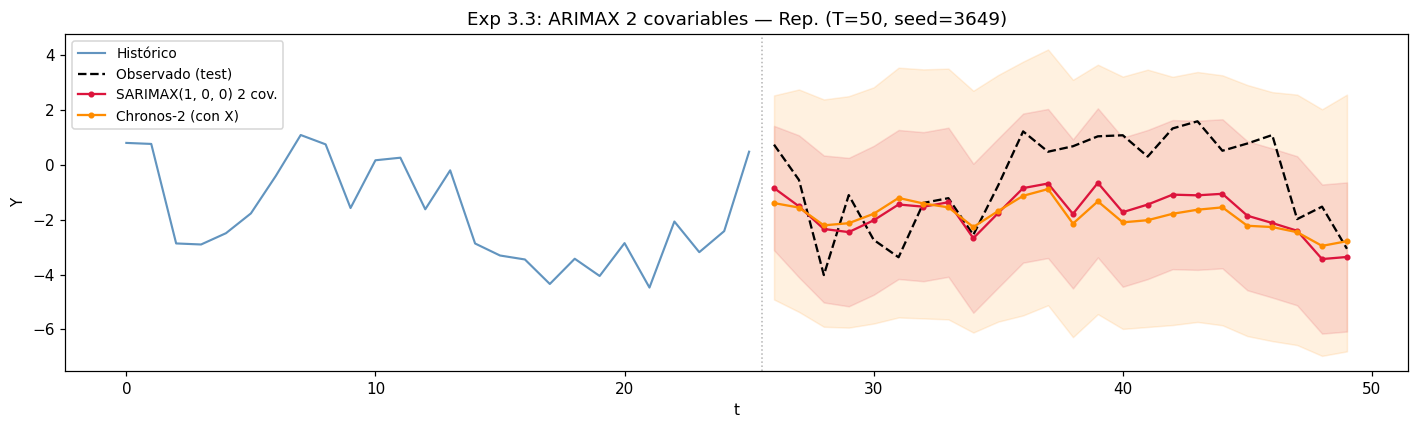

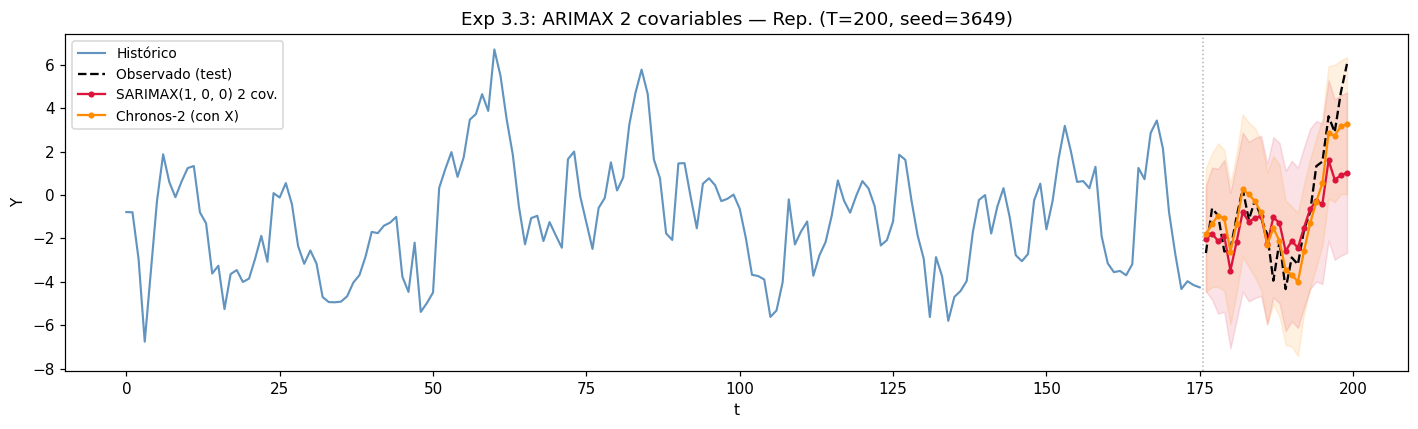

Tabla de métricas — Exp 3.3


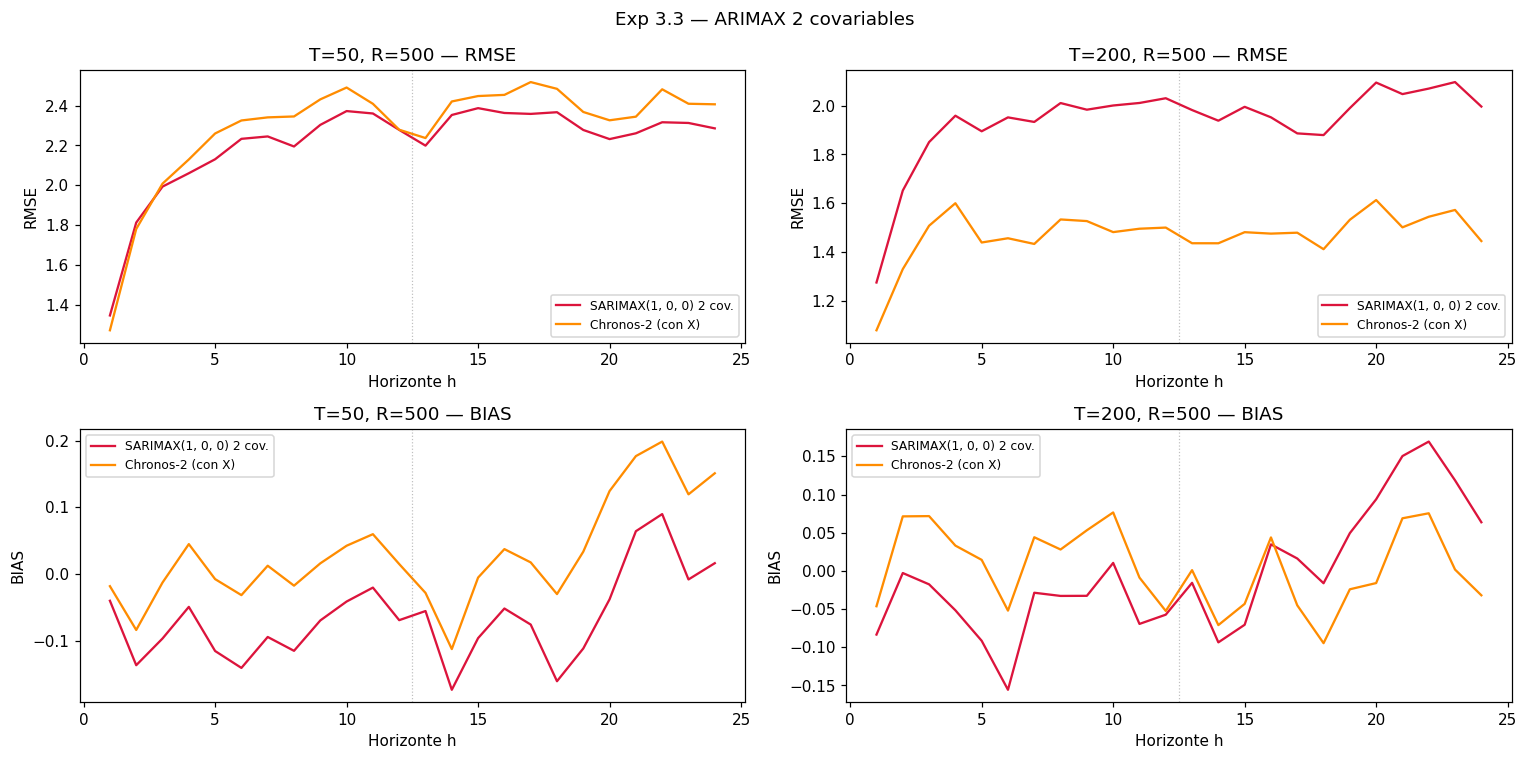

In [8]:
# Simulación representativa (T=T_LIST[0])
plot_rep_cov(
    dgp_3_3, make_models_3_3, dgp_params_3_3,
    T=T_LIST[0],
    title=f"Exp 3.3: ARIMAX 2 covariables — Rep. (T={T_LIST[0]}, seed={SEED})"
)

# Simulación representativa (T=T_LIST[1])
plot_rep_cov(
    dgp_3_3, make_models_3_3, dgp_params_3_3,
    T=T_LIST[1],
    title=f"Exp 3.3: ARIMAX 2 covariables — Rep. (T={T_LIST[1]}, seed={SEED})"
)

# Tabla de métricas
print("Tabla de métricas — Exp 3.3")
results_table(results_3_3)

# Gráficos de métricas por horizonte
plot_metrics(
    results_3_3,
    title=f"Exp 3.3 — ARIMAX 2 covariables",
    metrics=("rmse", "bias")
)

---
## Experimento 3.5

**DGP:** ARIMAX–GARCH — covariable en media y varianza

Media: $Y_t = 0.4\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$

Varianza: $\sigma_t^2 = 0.1 + 0.1\,\varepsilon_{t-1}^2 + 0.75\,\sigma_{t-1}^2 + 0.1\,X_t^2$

**Modelos:** SARIMAX (media con $X_t$), Chronos-2 con $X_t$

**Hipótesis:** SARIMAX captura el efecto de $X_t$ en la media pero ignora su impacto en la varianza. Chronos-con-X puede adaptar implícitamente la incertidumbre al nivel de $X_t$.

In [9]:
dgp_3_5         = ARIMAX_GARCH_DGP(seed=SEED)
make_models_3_5 = lambda T: [
    SARIMAXModel((1, 0, 0), name_suffix='con X'),
    chronos_cov1,
]
dgp_params_3_5  = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.1, sigma_x=1.0, rho_x=0.7)

results_3_5 = run_exp_cov(
    dgp_3_5, make_models_3_5, dgp_params_3_5,
    exp_id='3.5',
)

Exp 3.5: 2 ejecución(es) programada(s) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: cargando exp_3_5_T50_R500.csv ...
  T=200, R=500: cargando exp_3_5_T200_R500.csv ...


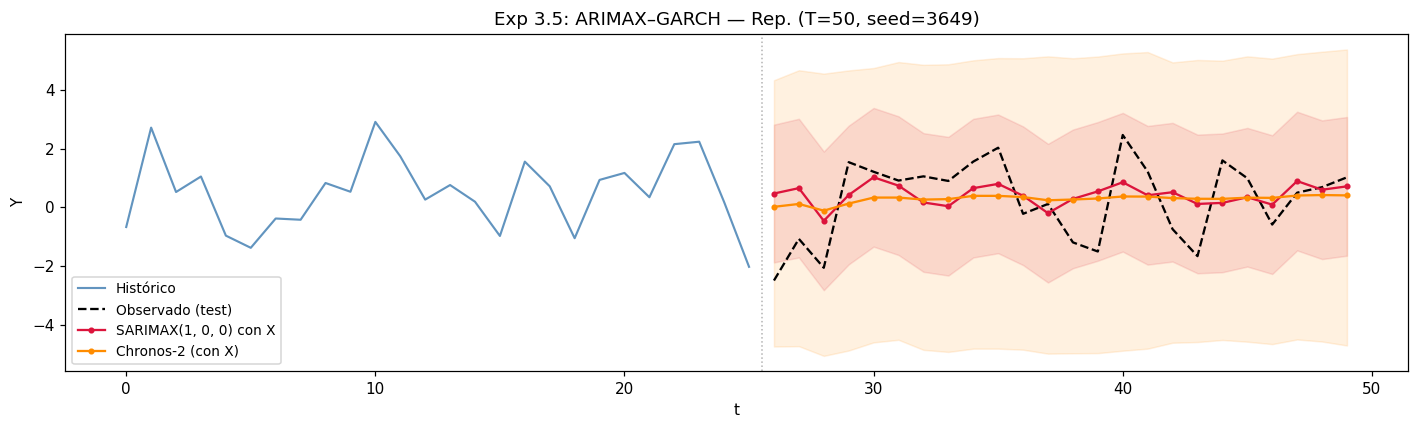

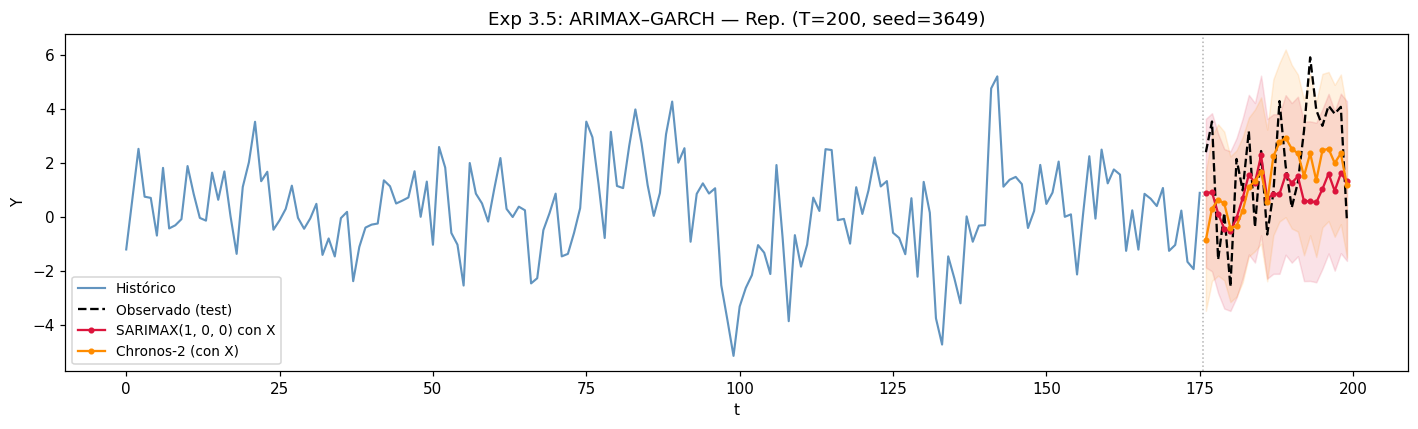

Tabla de métricas — Exp 3.5


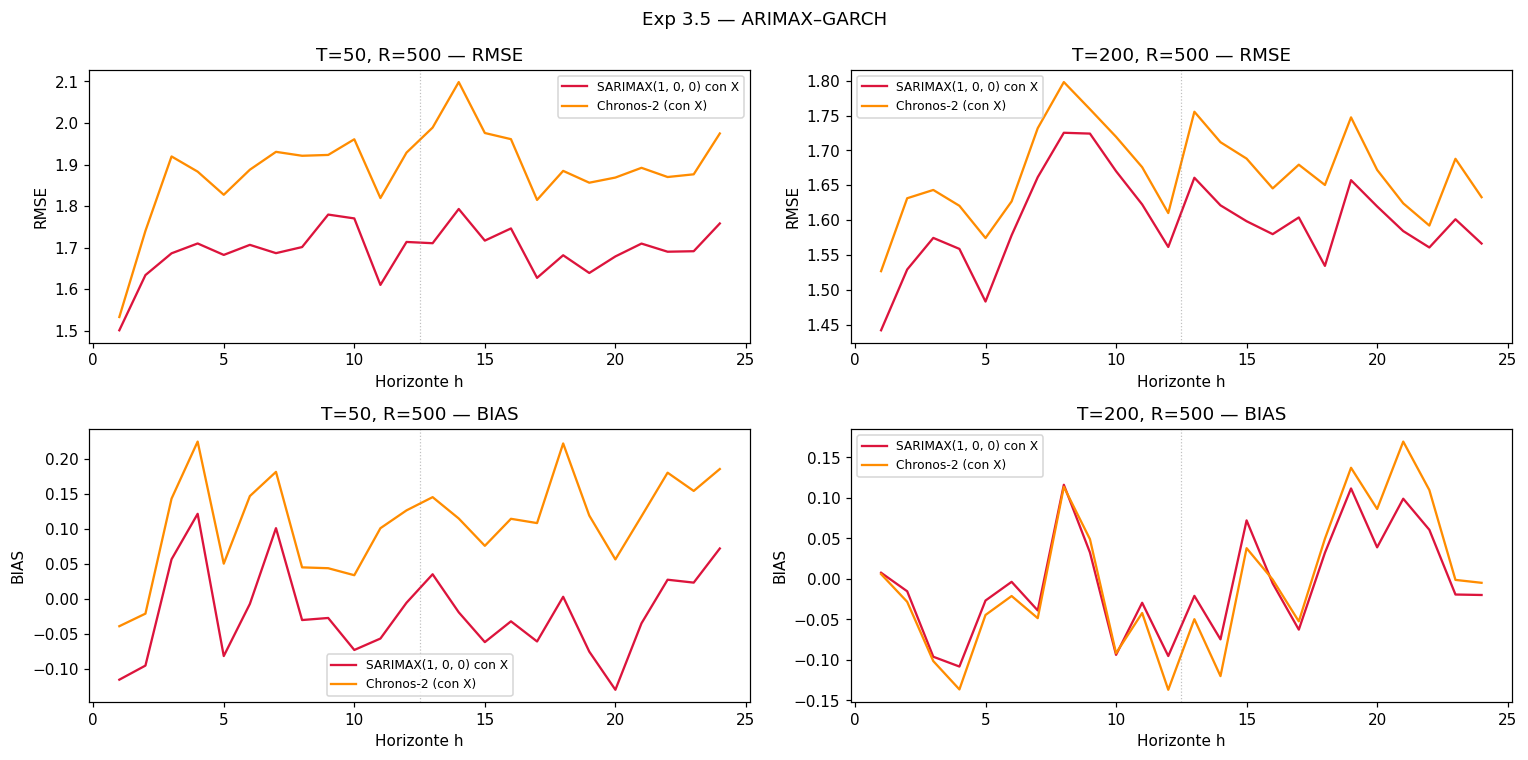

In [10]:
# Simulación representativa (T=T_LIST[0])
plot_rep_cov(
    dgp_3_5, make_models_3_5, dgp_params_3_5,
    T=T_LIST[0],
    title=f"Exp 3.5: ARIMAX–GARCH — Rep. (T={T_LIST[0]}, seed={SEED})"
)

# Simulación representativa (T=T_LIST[1])
plot_rep_cov(
    dgp_3_5, make_models_3_5, dgp_params_3_5,
    T=T_LIST[1],
    title=f"Exp 3.5: ARIMAX–GARCH — Rep. (T={T_LIST[1]}, seed={SEED})"
)

# Tabla de métricas
print("Tabla de métricas — Exp 3.5")
results_table(results_3_5)

# Gráficos de métricas por horizonte
plot_metrics(
    results_3_5,
    title=f"Exp 3.5 — ARIMAX–GARCH",
    metrics=("rmse", "bias")
)

---
## Experimento 3.6

**DGP:** ADL-ECM — covariable cointegrada $X_t \sim I(1)$

$$X_t = X_{t-1} + u_t, \quad u_t \sim N(0, 1)$$

$$\Delta Y_t = -0.3\,(Y_{t-1} - X_{t-1}) + \Delta X_t + \eta_t$$

La combinación $Y_t - X_t \sim I(0)$ (cointegración con vector $(1,-1)$).

**Modelos:** ARDL-ECM (estimación correcta del ECM), SARIMAX en diferencias (pierde la relación de largo plazo), SARIMAX en niveles (potencialmente espuria), Chronos-2 con $X_t$

**Hipótesis:** ARDL-ECM domina para $h$ grandes al capturar el mecanismo de corrección. SARIMAX en diferencias acumula sesgo. Chronos-2 con $X_t$ provisto puede descubrir implícitamente la tendencia común.

In [11]:
dgp_3_6         = ADL_ECM_DGP(seed=SEED)
make_models_3_6 = lambda T: [
    ARDLModel(),
    SARIMAXModel((1, 1, 0), name_suffix='dif. con X'),
    SARIMAXModel((1, 0, 0), name_suffix='niv. con X'),
    chronos_cov1,
]
dgp_params_3_6  = dict(alpha_ecm=-0.3, sigma=1.0, sigma_x=1.0)

results_3_6 = run_exp_cov(
    dgp_3_6, make_models_3_6, dgp_params_3_6,
    exp_id='3.6',
)

Exp 3.6: 2 ejecución(es) programada(s) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: cargando exp_3_6_T50_R500.csv ...
  T=200, R=500: cargando exp_3_6_T200_R500.csv ...


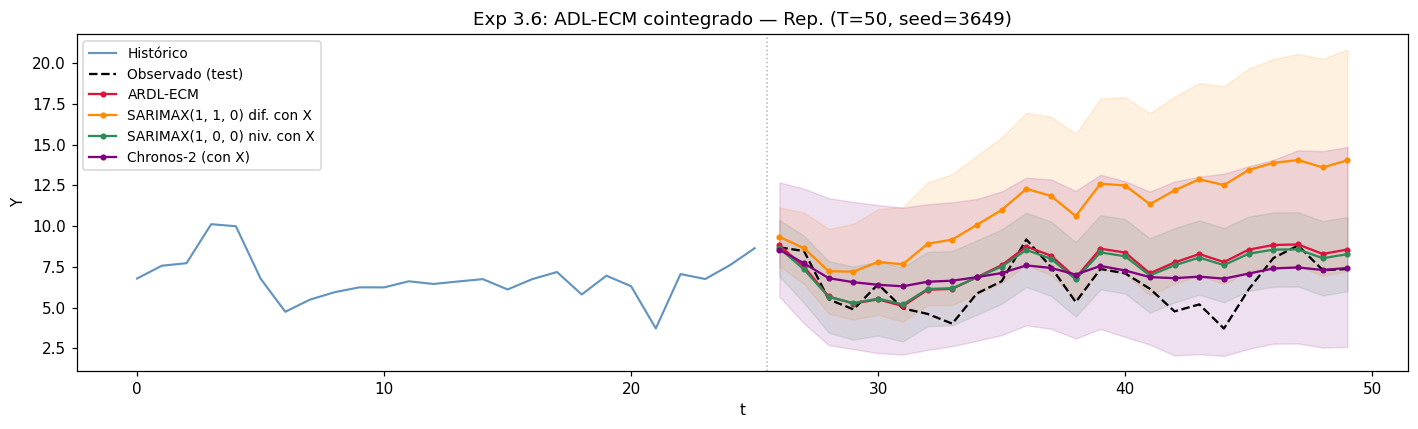

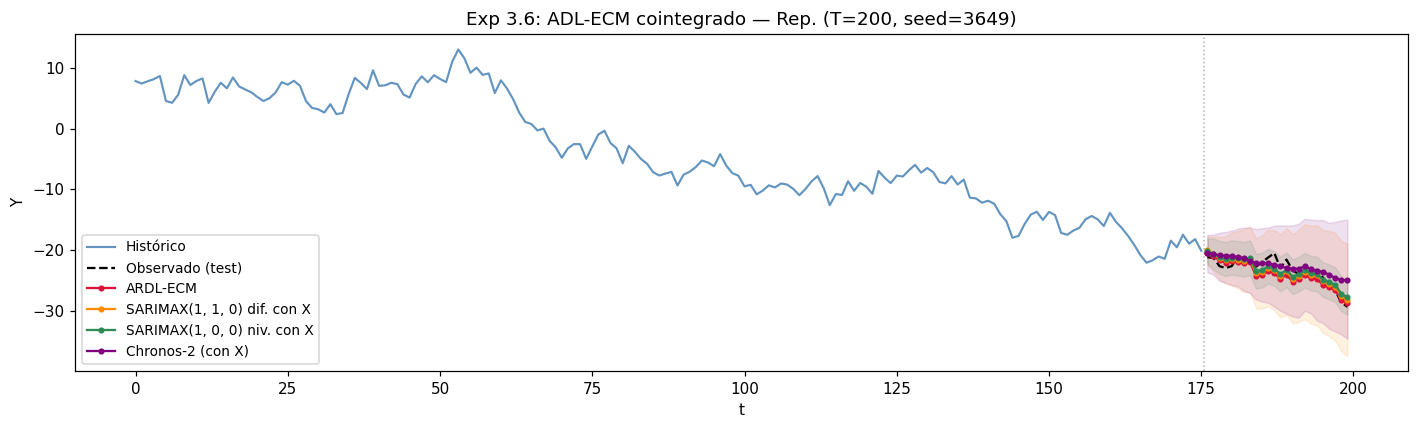

Tabla de métricas — Exp 3.6


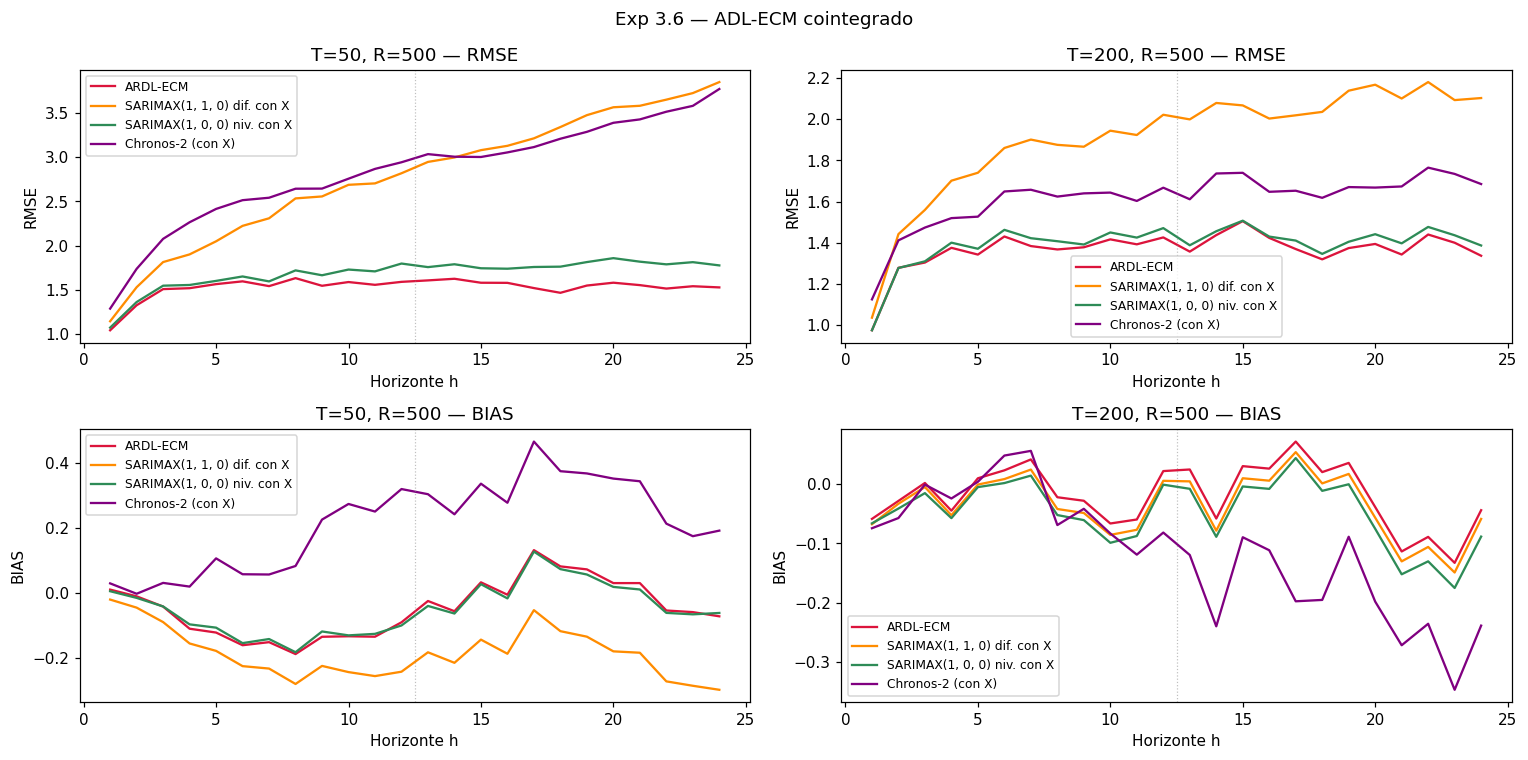

In [12]:
# Simulación representativa (T=T_LIST[0])
plot_rep_cov(
    dgp_3_6, make_models_3_6, dgp_params_3_6,
    T=T_LIST[0],
    title=f"Exp 3.6: ADL-ECM cointegrado — Rep. (T={T_LIST[0]}, seed={SEED})"
)

# Simulación representativa (T=T_LIST[1])
plot_rep_cov(
    dgp_3_6, make_models_3_6, dgp_params_3_6,
    T=T_LIST[1],
    title=f"Exp 3.6: ADL-ECM cointegrado — Rep. (T={T_LIST[1]}, seed={SEED})"
)

# Tabla de métricas
print("Tabla de métricas — Exp 3.6")
results_table(results_3_6)

# Gráficos de métricas por horizonte
plot_metrics(
    results_3_6,
    title=f"Exp 3.6 — ADL-ECM cointegrado",
    metrics=("rmse", "bias")
)

---
## Experimento 3.4

**DGP:** VARX bivariado — efecto exógeno conjunto

$$Y_t = A\,Y_{t-1} + \gamma\,X_t + \varepsilon_t, \quad A = \begin{pmatrix}0.5&0.1\\0.1&0.5\end{pmatrix}, \quad \gamma = (0.5, 0.3)^{\top}$$

$$X_t = 0.7\,X_{t-1} + \eta_t \quad (\text{escalar estacionario})$$

**Modelos:** VARMAX(1) con $X_t$, Chronos-2 joint con $X_t$

**Hipótesis:** VARMAX especifica explícitamente el efecto exógeno en el sistema bivariado; Chronos-2 joint con $X_t$ debería capturarlo implícitamente via sus mecanismos de atención.

In [13]:
dgp_3_4         = VARX_DGP(seed=SEED, A=[[0.5, 0.1], [0.1, 0.5]], gamma=[0.5, 0.3], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
make_models_3_4 = lambda T: [
    VARMAXModel(1),
    chronos_mv_cov1,
]
dgp_params_3_4  = {}
var_names_3_4   = ["Y1", "Y2"]

results_3_4 = run_exp_mv_cov(
    dgp_3_4, make_models_3_4, dgp_params_3_4,
    exp_id='3.4',
)

Exp 3.4: 2 ejecución(es) programada(s) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: simulando ... OK (328s)
  T=200, R=500: simulando ... OK (492s)


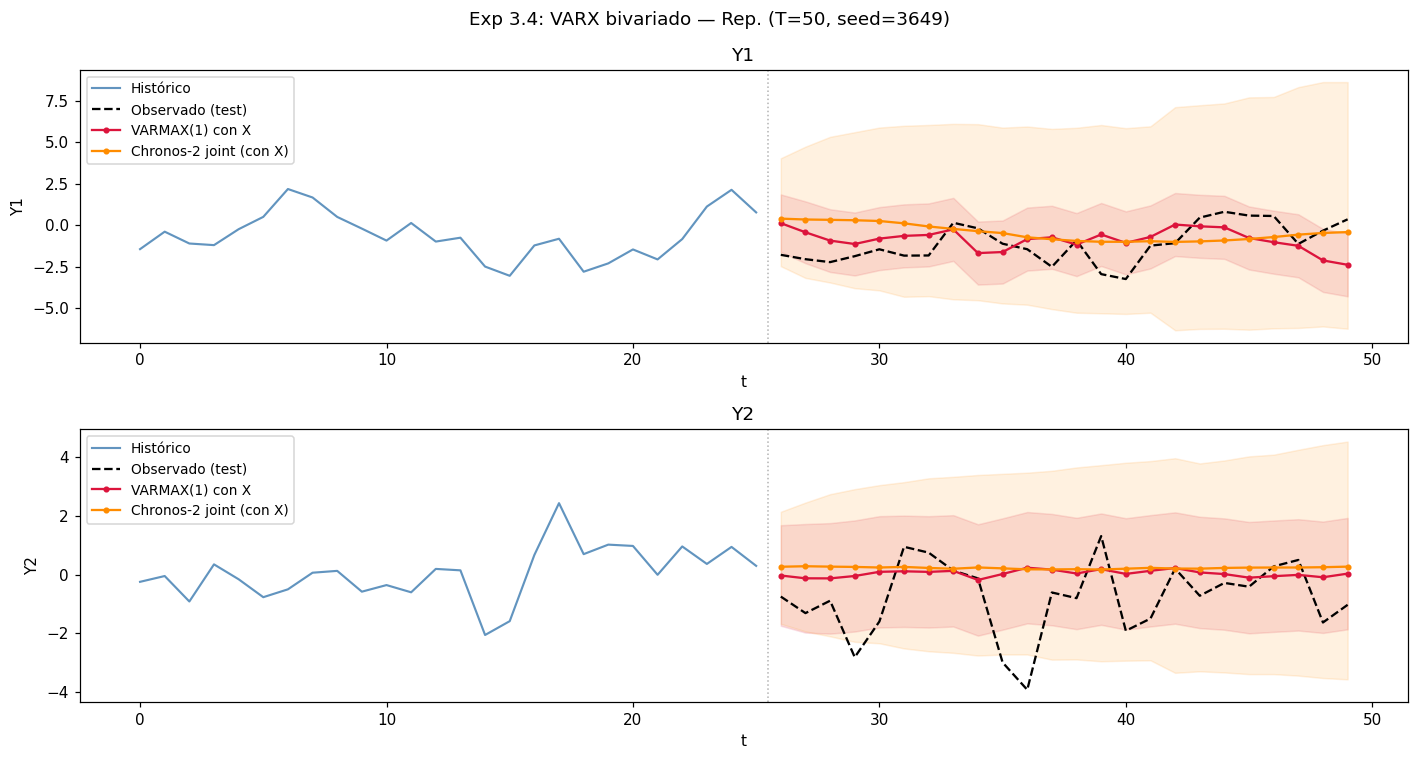

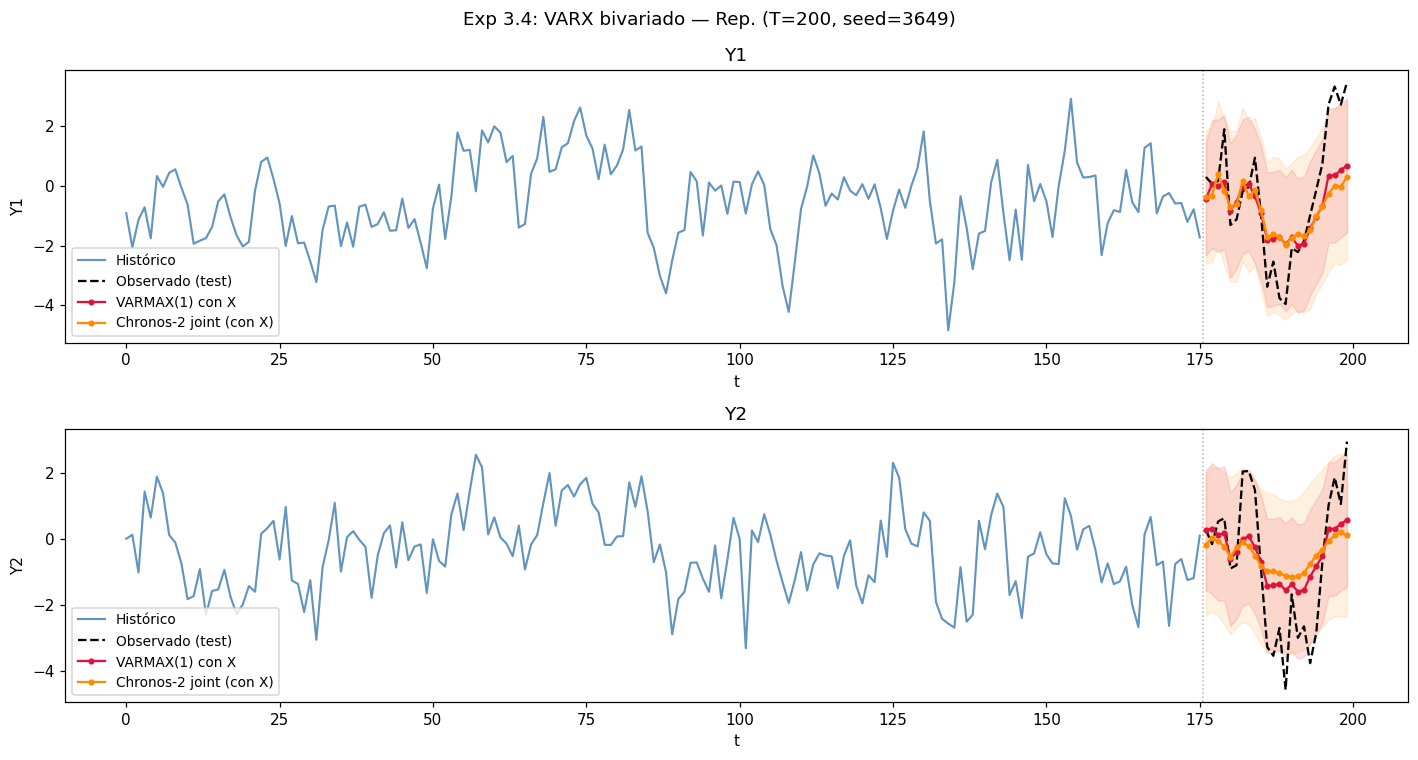

Tabla de métricas — Exp 3.4


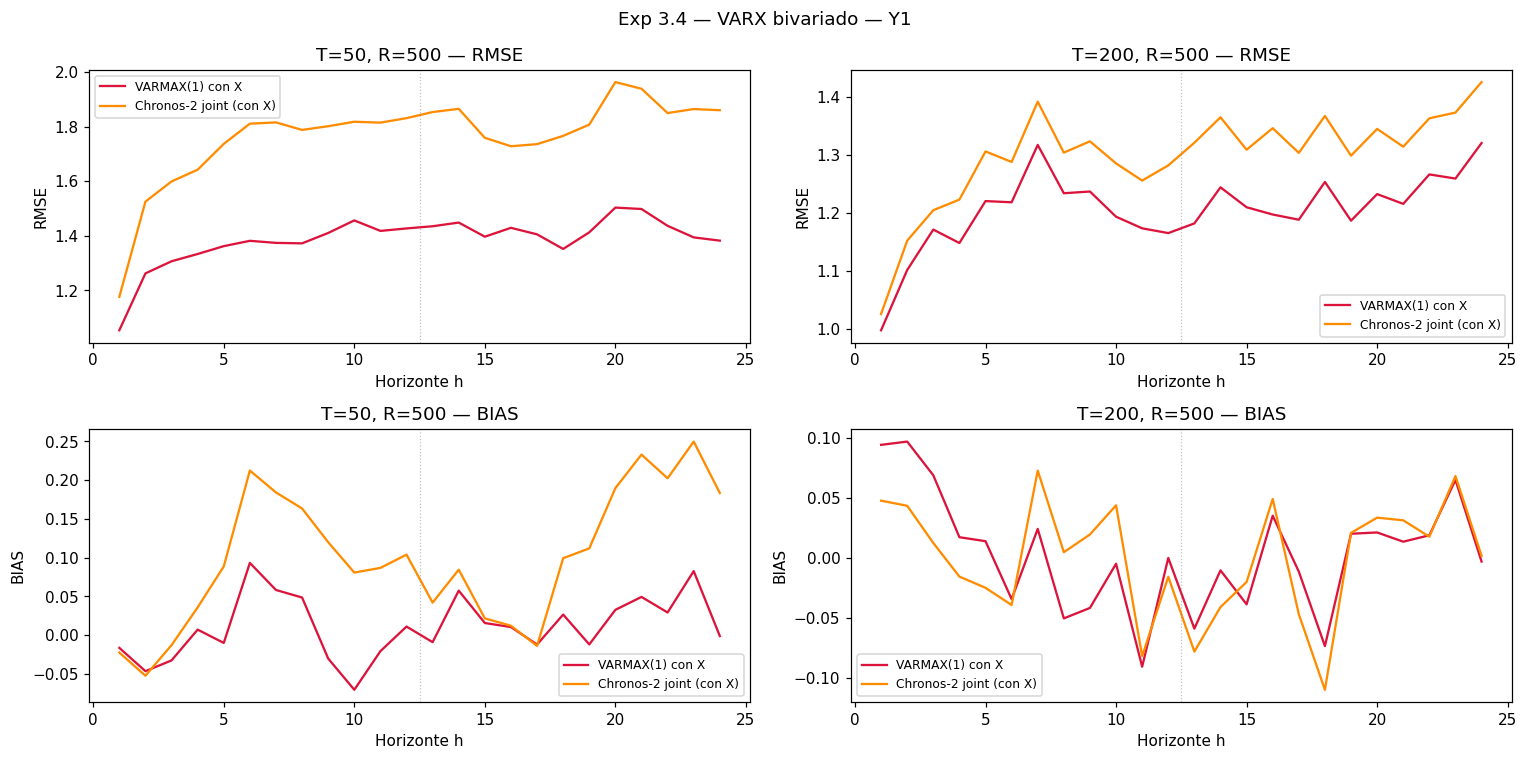

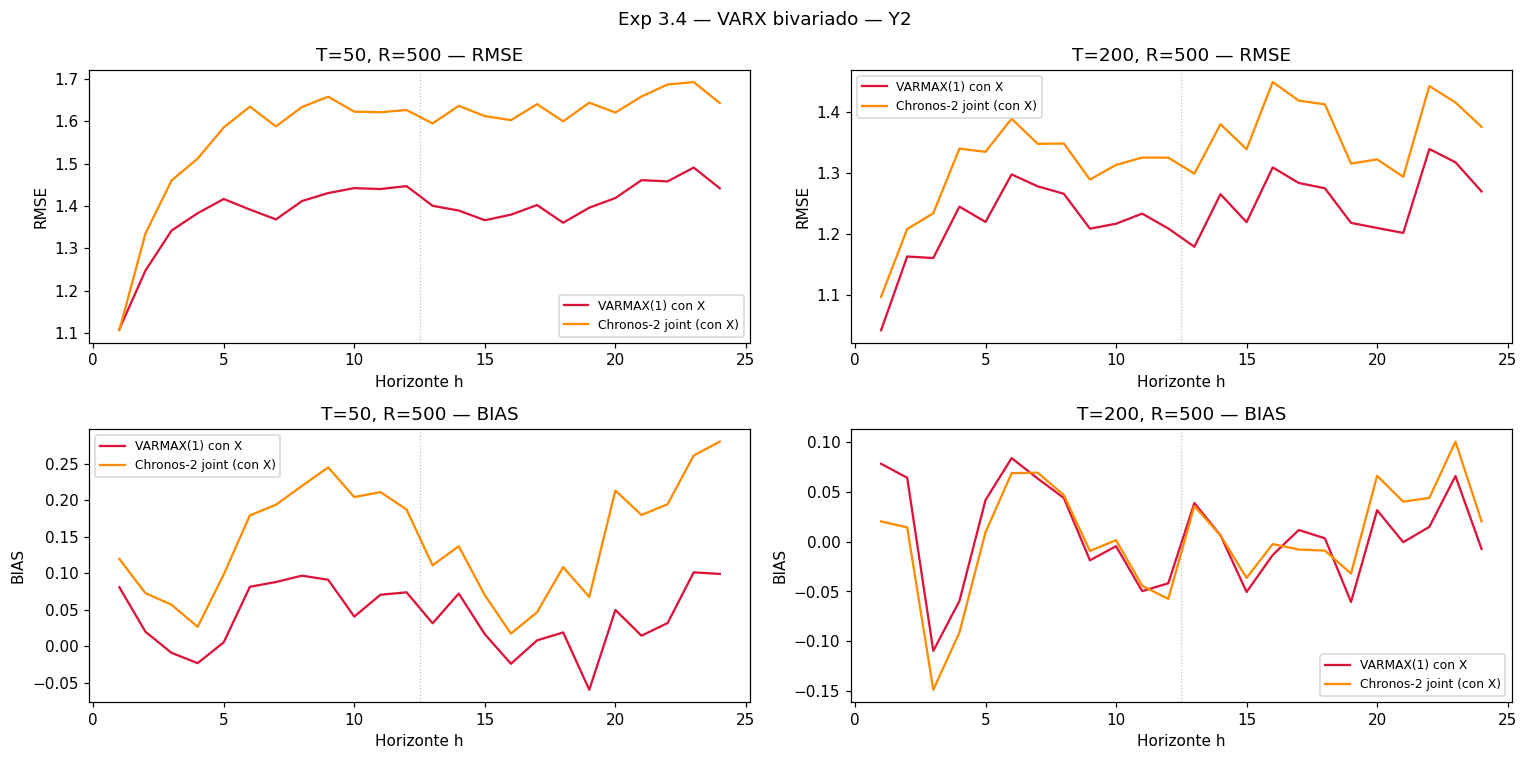

In [14]:
# Simulación representativa (T=T_LIST[0])
plot_rep_mv_cov(
    dgp_3_4, make_models_3_4, dgp_params_3_4,
    var_names=var_names_3_4,
    T=T_LIST[0],
    title=f"Exp 3.4: VARX bivariado — Rep. (T={T_LIST[0]}, seed={SEED})"
)

# Simulación representativa (T=T_LIST[1])
plot_rep_mv_cov(
    dgp_3_4, make_models_3_4, dgp_params_3_4,
    var_names=var_names_3_4,
    T=T_LIST[1],
    title=f"Exp 3.4: VARX bivariado — Rep. (T={T_LIST[1]}, seed={SEED})"
)

# Tabla de métricas por variable
print("Tabla de métricas — Exp 3.4")
results_table_mv(results_3_4, var_names=var_names_3_4)

# Gráficos de métricas
plot_metrics_mv(
    results_3_4,
    var_names=var_names_3_4,
    title=f"Exp 3.4 — VARX bivariado",
    metrics=("rmse", "bias")
)